# Workflow 2 — Leakage experiment v3
## Audited vs unaudited BRISC 2025 — fixed dataframe shuffle + TF 2.19 val

**Catarina Bota | UCP**

Third iteration. Same coursework-faithful training config but with two fixes over the previous notebook:

1. **Dataframes are shuffled deterministically** (`sample(frac=1, random_state=42)`) before Keras' `validation_split` slices the last 20%. Without this, val_gen is dominated by the last-appended class (pituitary) and val_accuracy is ~0%.
2. **`val_gen shuffle=False`** — required on TF 2.19 for stable per-epoch validation. TF 2.20 on Colab tolerated `shuffle=True`; 2.19 does not.

**Config still mirrors the coursework:**
- 3-block CNN (32/64/128 Conv2D + MaxPool), Flatten, Dense(128, ReLU), **Dropout(0.5)**, Dense(4, softmax)
- Adam optimiser (default LR)
- `EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)`
- **No** ReduceLROnPlateau
- 30 epochs cap, batch 32, image 128×128, val_split 0.2, augmentation identical

**Runtime**: ~10 min per dataset on RTX 4060 WSL2.

In [1]:
import os, json, time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import warnings
warnings.filterwarnings('ignore')

import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import EarlyStopping

from sklearn.metrics import (confusion_matrix, accuracy_score,
                              precision_score, recall_score, f1_score,
                              roc_auc_score, precision_recall_fscore_support)

print('TF:', tf.__version__)
gpus = tf.config.list_physical_devices('GPU')
print('GPUs:', gpus)
for g in gpus:
    tf.config.experimental.set_memory_growth(g, True)

2026-07-01 14:36:31.467048: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-07-01 14:36:31.493505: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1782912991.511109   16454 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1782912991.517405   16454 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1782912991.536967   16454 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking 

TF: 2.19.0
GPUs: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [2]:
IMG_SIZE   = 128
BATCH_SIZE = 32
EPOCHS     = 30
CLASSES    = ['glioma', 'meningioma', 'no_tumor', 'pituitary']
N_CLASSES  = len(CLASSES)
SEED       = 42

EXPERIMENTS = {
    'audited':   '/root/brisc/data/brisc2025_clean/classification_task',
    'unaudited': '/root/brisc/data_unaudited/classification_task',
}
OUT_ROOT = '/mnt/c/Users/cbot/Desktop/BRISC pos graduação/brisc_gui/leakage_v3'
os.makedirs(OUT_ROOT, exist_ok=True)

In [3]:
def build_paths_df(base_dir):
    """Build train_df and test_df from a base directory of class subfolders,
    then SHUFFLE deterministically so that Keras' validation_split is class-balanced."""
    out = {}
    for split in ('train', 'test'):
        rows = []
        for cls in CLASSES:
            d = f'{base_dir}/{split}/{cls}'
            for fn in sorted(os.listdir(d)):
                if fn.lower().endswith(('.jpg', '.jpeg', '.png')):
                    rows.append({'path': f'{d}/{fn}', 'label': cls})
        df = pd.DataFrame(rows).sample(frac=1, random_state=SEED).reset_index(drop=True)
        out[split] = df
    return out['train'], out['test']


def build_cnn():
    m = models.Sequential([
        layers.Input(shape=(IMG_SIZE, IMG_SIZE, 3)),
        layers.Conv2D(32,  (3,3), activation='relu', padding='same'),
        layers.MaxPooling2D((2,2)),
        layers.Conv2D(64,  (3,3), activation='relu', padding='same'),
        layers.MaxPooling2D((2,2)),
        layers.Conv2D(128, (3,3), activation='relu', padding='same'),
        layers.MaxPooling2D((2,2)),
        layers.Flatten(),
        layers.Dense(128, activation='relu'),
        layers.Dropout(0.5),
        layers.Dense(N_CLASSES, activation='softmax'),
    ])
    m.compile(optimizer='adam',
              loss='categorical_crossentropy',
              metrics=['accuracy'])
    return m


def make_generators(train_df, test_df):
    train_datagen = ImageDataGenerator(
        rescale=1./255,
        rotation_range=10, zoom_range=0.1,
        width_shift_range=0.05, height_shift_range=0.05,
        horizontal_flip=True,
        validation_split=0.2)
    test_datagen = ImageDataGenerator(rescale=1./255)
    tr = train_datagen.flow_from_dataframe(
        train_df, x_col='path', y_col='label',
        target_size=(IMG_SIZE, IMG_SIZE), batch_size=BATCH_SIZE,
        class_mode='categorical', classes=CLASSES,
        subset='training', shuffle=True, seed=SEED)
    va = train_datagen.flow_from_dataframe(
        train_df, x_col='path', y_col='label',
        target_size=(IMG_SIZE, IMG_SIZE), batch_size=BATCH_SIZE,
        class_mode='categorical', classes=CLASSES,
        subset='validation', shuffle=False, seed=SEED)
    te = test_datagen.flow_from_dataframe(
        test_df, x_col='path', y_col='label',
        target_size=(IMG_SIZE, IMG_SIZE), batch_size=BATCH_SIZE,
        class_mode='categorical', classes=CLASSES,
        shuffle=False)
    return tr, va, te

In [4]:
def bootstrap_acc_ci(y_true, y_pred, n_iter=1000, alpha=0.05, seed=42):
    y_true = np.asarray(y_true); y_pred = np.asarray(y_pred)
    rng = np.random.RandomState(seed)
    n = len(y_true); accs = []
    for _ in range(n_iter):
        idx = rng.randint(0, n, n)
        accs.append((y_true[idx] == y_pred[idx]).mean() * 100)
    return float(np.percentile(accs, 100 * alpha / 2)), \
           float(np.percentile(accs, 100 * (1 - alpha / 2)))

def evaluate_on_test(model, test_gen):
    test_gen.reset()
    y_true = np.asarray(test_gen.classes)
    y_proba = model.predict(test_gen, verbose=0)
    y_pred = np.argmax(y_proba, axis=1)
    return y_true, y_pred, y_proba

def run_experiment(name, base_dir):
    print('=' * 60); print(f'  EXPERIMENT: {name}'); print(f'  Data: {base_dir}'); print('=' * 60)
    out_dir = f'{OUT_ROOT}/{name}'; os.makedirs(out_dir, exist_ok=True)

    train_df, test_df = build_paths_df(base_dir)
    print(f'  train_df: {len(train_df)}   test_df: {len(test_df)}')

    tr, va, te = make_generators(train_df, test_df)
    model = build_cnn()

    es = EarlyStopping(monitor='val_loss', patience=5,
                        restore_best_weights=True, verbose=1)
    t0 = time.time()
    hist = model.fit(tr, validation_data=va, epochs=EPOCHS, callbacks=[es], verbose=2)
    train_time = time.time() - t0

    y_true, y_pred, y_proba = evaluate_on_test(model, te)
    acc = accuracy_score(y_true, y_pred) * 100
    f1  = f1_score(y_true, y_pred, average='macro') * 100
    auc = roc_auc_score(y_true, y_proba, multi_class='ovr', average='macro') * 100
    ci_lo, ci_hi = bootstrap_acc_ci(y_true, y_pred)

    print(f'\n  Test Accuracy : {acc:.2f}%   CI95 [{ci_lo:.2f}, {ci_hi:.2f}]')
    print(f'  Test F1 macro : {f1:.2f}%')
    print(f'  Test AUC OvR  : {auc:.2f}%')
    print(f'  Epochs run    : {len(hist.history["loss"])}   (train time {train_time:.1f}s)')
    print(f'  Best epoch    : {np.argmin(hist.history["val_loss"]) + 1} (min val_loss)')

    model.save(f'{out_dir}/model.h5')
    pd.DataFrame({'y_true': y_true, 'y_pred': y_pred}) \
      .to_csv(f'{out_dir}/predictions.csv', index=False)
    pd.DataFrame(confusion_matrix(y_true, y_pred), index=CLASSES, columns=CLASSES) \
      .to_csv(f'{out_dir}/confusion_matrix.csv')
    prec_c, rec_c, f1_c, sup_c = precision_recall_fscore_support(
        y_true, y_pred, labels=range(N_CLASSES))
    pd.DataFrame({
        'class': CLASSES,
        'precision': (prec_c * 100).round(2),
        'recall':    (rec_c * 100).round(2),
        'f1':        (f1_c * 100).round(2),
        'support':   sup_c.astype(int),
    }).to_csv(f'{out_dir}/perclass.csv', index=False)
    with open(f'{out_dir}/history.json', 'w') as f:
        json.dump({k: [float(x) for x in v] for k, v in hist.history.items()}, f, indent=2)

    return {
        'experiment': name,
        'train_imgs': tr.samples,
        'val_imgs':   va.samples,
        'test_imgs':  te.samples,
        'accuracy':   round(acc, 2),
        'f1_macro':   round(f1, 2),
        'auc_ovr':    round(auc, 2),
        'ci95_lo':    round(ci_lo, 2),
        'ci95_hi':    round(ci_hi, 2),
        'epochs_run': len(hist.history['loss']),
        'train_time_s': round(train_time, 1),
    }

results = [run_experiment(n, b) for n, b in EXPERIMENTS.items()]

  EXPERIMENT: audited
  Data: /root/brisc/data/brisc2025_clean/classification_task
  train_df: 4363   test_df: 678
Found 3491 validated image filenames belonging to 4 classes.
Found 872 validated image filenames belonging to 4 classes.
Found 678 validated image filenames belonging to 4 classes.


I0000 00:00:1782912994.171684   16454 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 5560 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 4060 Laptop GPU, pci bus id: 0000:01:00.0, compute capability: 8.9


Epoch 1/30


I0000 00:00:1782912996.095053   16541 service.cc:152] XLA service 0x787370019710 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1782912996.095109   16541 service.cc:160]   StreamExecutor device (0): NVIDIA GeForce RTX 4060 Laptop GPU, Compute Capability 8.9
2026-07-01 14:36:36.122409: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
I0000 00:00:1782912996.345614   16541 cuda_dnn.cc:529] Loaded cuDNN version 90300
2026-07-01 14:36:39.006490: E external/local_xla/xla/service/slow_operation_alarm.cc:73] Trying algorithm eng12{k11=0} for conv %cudnn-conv-bias-activation.9 = (f32[32,32,128,128]{3,2,1,0}, u8[0]{0}) custom-call(f32[32,3,128,128]{3,2,1,0} %bitcast.4907, f32[32,3,3,3]{3,2,1,0} %bitcast.4898, f32[32]{0} %bitcast.5222), window={size=3x3 pad=1_1x1_1}, dim_labels=bf01_oi01->bf01, custom_call_target="__cudnn$convBiasActivati

110/110 - 21s - 189ms/step - accuracy: 0.5597 - loss: 1.0594 - val_accuracy: 0.7374 - val_loss: 0.6919
Epoch 2/30
110/110 - 10s - 91ms/step - accuracy: 0.7319 - loss: 0.6892 - val_accuracy: 0.8028 - val_loss: 0.5341
Epoch 3/30
110/110 - 10s - 90ms/step - accuracy: 0.7708 - loss: 0.5834 - val_accuracy: 0.8211 - val_loss: 0.4444
Epoch 4/30
110/110 - 10s - 90ms/step - accuracy: 0.7986 - loss: 0.5082 - val_accuracy: 0.8303 - val_loss: 0.4297
Epoch 5/30
110/110 - 10s - 89ms/step - accuracy: 0.8138 - loss: 0.4784 - val_accuracy: 0.8567 - val_loss: 0.3860
Epoch 6/30
110/110 - 10s - 90ms/step - accuracy: 0.8258 - loss: 0.4512 - val_accuracy: 0.8532 - val_loss: 0.3856
Epoch 7/30
110/110 - 10s - 88ms/step - accuracy: 0.8364 - loss: 0.4233 - val_accuracy: 0.8658 - val_loss: 0.3511
Epoch 8/30
110/110 - 10s - 88ms/step - accuracy: 0.8384 - loss: 0.4076 - val_accuracy: 0.8693 - val_loss: 0.3592
Epoch 9/30
110/110 - 10s - 90ms/step - accuracy: 0.8476 - loss: 0.3745 - val_accuracy: 0.8842 - val_loss: 


  Test Accuracy : 93.07%   CI95 [91.15, 94.69]
  Test F1 macro : 93.27%
  Test AUC OvR  : 99.35%
  Epochs run    : 30   (train time 306.9s)
  Best epoch    : 26 (min val_loss)
  EXPERIMENT: unaudited
  Data: /root/brisc/data_unaudited/classification_task
  train_df: 5000   test_df: 1000
Found 4000 validated image filenames belonging to 4 classes.
Found 1000 validated image filenames belonging to 4 classes.
Found 1000 validated image filenames belonging to 4 classes.
Epoch 1/30
125/125 - 15s - 119ms/step - accuracy: 0.5955 - loss: 0.9952 - val_accuracy: 0.7440 - val_loss: 0.6175
Epoch 2/30
125/125 - 11s - 91ms/step - accuracy: 0.7577 - loss: 0.6498 - val_accuracy: 0.8000 - val_loss: 0.4994
Epoch 3/30
125/125 - 12s - 93ms/step - accuracy: 0.7875 - loss: 0.5480 - val_accuracy: 0.8030 - val_loss: 0.4844
Epoch 4/30
125/125 - 12s - 94ms/step - accuracy: 0.8100 - loss: 0.4835 - val_accuracy: 0.8410 - val_loss: 0.3866
Epoch 5/30
125/125 - 12s - 93ms/step - accuracy: 0.8213 - loss: 0.4587 - va


  Test Accuracy : 94.20%   CI95 [92.80, 95.60]
  Test F1 macro : 94.03%
  Test AUC OvR  : 99.47%
  Epochs run    : 30   (train time 343.5s)
  Best epoch    : 29 (min val_loss)


In [5]:
df = pd.DataFrame(results).set_index('experiment')
print(df.to_string())
df.to_csv(f'{OUT_ROOT}/comparison.csv')

if {'audited', 'unaudited'}.issubset(df.index):
    delta = df.loc['unaudited', 'accuracy'] - df.loc['audited', 'accuracy']
    ci_a = (df.loc['audited', 'ci95_lo'], df.loc['audited', 'ci95_hi'])
    ci_u = (df.loc['unaudited', 'ci95_lo'], df.loc['unaudited', 'ci95_hi'])
    overlap = not (ci_a[1] < ci_u[0] or ci_u[1] < ci_a[0])
    print('\n' + '=' * 60)
    print('  LEAKAGE DELTA (unaudited - audited)')
    print('=' * 60)
    print(f'  Δ Accuracy   : {delta:+.2f} pp')
    print(f'  95% CIs overlap? {"yes" if overlap else "NO — statistically robust delta"}')

            train_imgs  val_imgs  test_imgs  accuracy  f1_macro  auc_ovr  ci95_lo  ci95_hi  epochs_run  train_time_s
experiment                                                                                                          
audited           3491       872        678     93.07     93.27    99.35    91.15    94.69          30         306.9
unaudited         4000      1000       1000     94.20     94.03    99.47    92.80    95.60          30         343.5

  LEAKAGE DELTA (unaudited - audited)
  Δ Accuracy   : +1.13 pp
  95% CIs overlap? yes


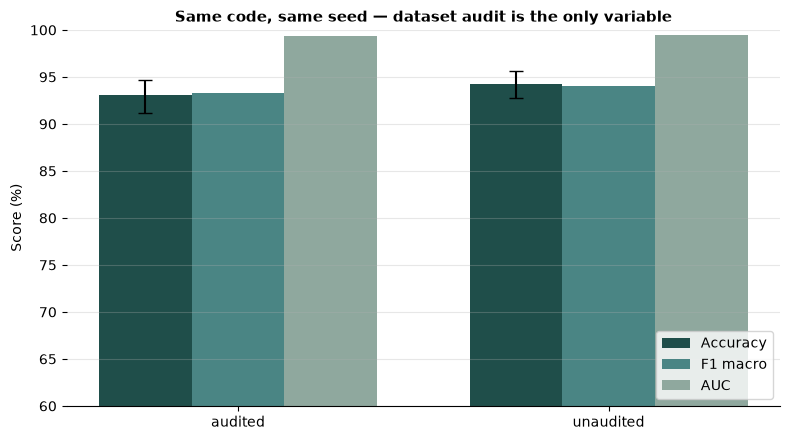

In [6]:
if len(df) >= 2:
    fig, ax = plt.subplots(figsize=(8, 4.5))
    x = np.arange(len(df)); w = 0.25
    ax.bar(x - w, df['accuracy'], w, label='Accuracy', color='#1F4E4A')
    ax.bar(x,     df['f1_macro'], w, label='F1 macro', color='#4A8584')
    ax.bar(x + w, df['auc_ovr'],  w, label='AUC',      color='#8FA89E')
    for i, r in enumerate(df.itertuples()):
        ax.errorbar(i - w, r.accuracy,
                    yerr=[[r.accuracy - r.ci95_lo], [r.ci95_hi - r.accuracy]],
                    fmt='none', ecolor='black', capsize=5)
    ax.set_xticks(x); ax.set_xticklabels(df.index)
    ax.set_ylim([60, 100]); ax.set_ylabel('Score (%)')
    ax.set_title('Same code, same seed — dataset audit is the only variable',
                 fontsize=11, fontweight='bold')
    ax.legend(loc='lower right')
    for s in ['top', 'right', 'left']: ax.spines[s].set_visible(False)
    ax.grid(axis='y', alpha=0.3)
    plt.tight_layout()
    plt.savefig(f'{OUT_ROOT}/comparison.png', dpi=150, bbox_inches='tight')
    plt.show()